 ## Step1 Data Auditing & Structural Prep

In [2]:
#Loading the dataset
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df=pd.read_csv(r"C:\Users\hh\Downloads\ecommerce_sales_analytics_5000.csv" , 
               parse_dates=['order_date'])
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          5000 non-null   int64         
 1   order_date        5000 non-null   datetime64[ns]
 2   customer_id       5000 non-null   int64         
 3   product_category  5000 non-null   object        
 4   region            5000 non-null   object        
 5   quantity          5000 non-null   int64         
 6   unit_price        5000 non-null   float64       
 7   discount          5000 non-null   float64       
 8   payment_method    5000 non-null   object        
 9   delivery_days     5000 non-null   int64         
 10  customer_rating   5000 non-null   float64       
 11  revenue           5000 non-null   float64       
dtypes: datetime64[ns](1), float64(4), int64(4), object(3)
memory usage: 468.9+ KB


In [3]:
df.isna().sum()

order_id            0
order_date          0
customer_id         0
product_category    0
region              0
quantity            0
unit_price          0
discount            0
payment_method      0
delivery_days       0
customer_rating     0
revenue             0
dtype: int64

Question 1: The Fulfillment Breaking Point

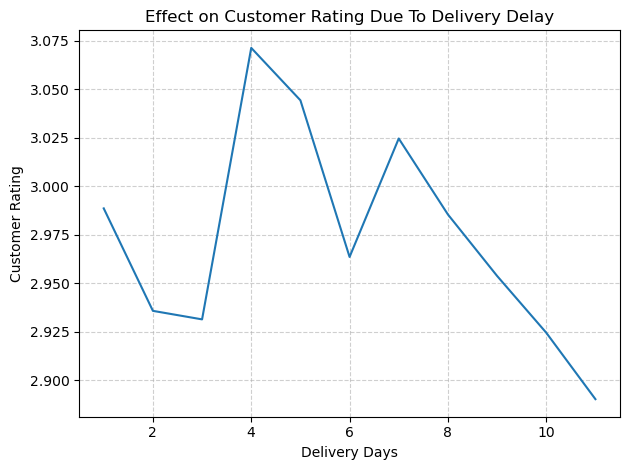

In [4]:

relation=df.groupby("delivery_days")["customer_rating"].mean()
sns.lineplot(relation)
plt.xlabel("Delivery Days")
plt.ylabel("Customer Rating")
plt.title("Effect on Customer Rating Due To Delivery Delay")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Observation
During the analysis of effects of delivery delays onto customer ratings.It was seen that Day 1 till Day 5 the customer's satisfaction rate was quite good and the ratings also witnessed its high,but from Day 6 till Day 11 the rating started to see a drop that might be due the frustration of customers due to delay in getting their product.

Question 2: Regional Fulfillment Bottlenecks

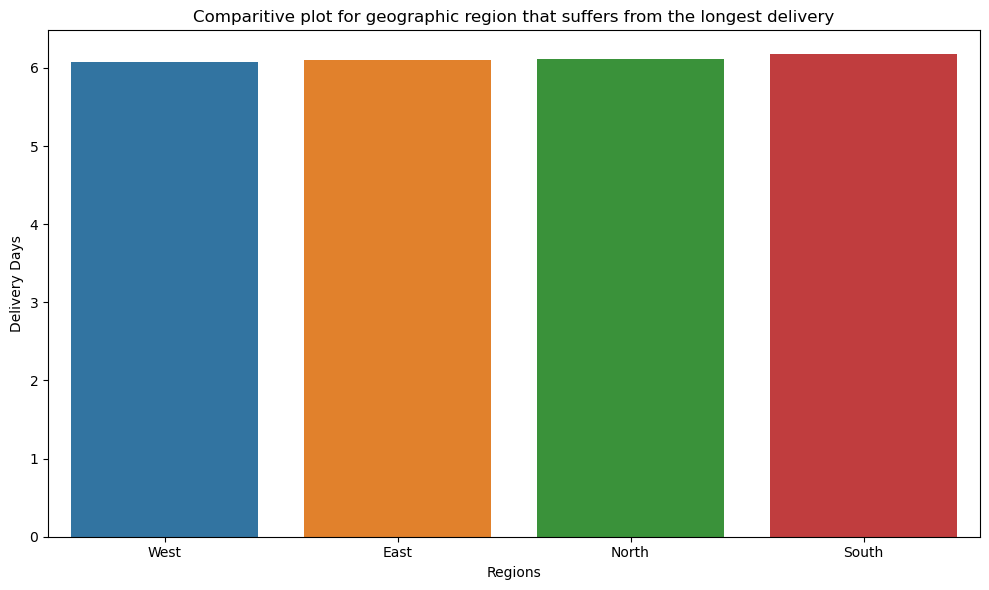

In [24]:
geographic_region=(df.groupby("region")['delivery_days'].mean().sort_values(ascending=True))

plt.figure(figsize=(10,6))
sns.barplot(x=geographic_region.index,
           y=geographic_region.values
)
plt.xlabel("Regions")
plt.ylabel("Delivery Days")
plt.title("Comparitive plot for geographic region that suffers from the longest delivery")

plt.tight_layout()
plt.show()

Observation
In every region the average delivery day is approx 6 days but in Southern region it was recorded that delivery days took longer.6.5 days.This indicates that company's allover delivery system has an issue

Question 3: The Discount vs. Revenue Trade-Off

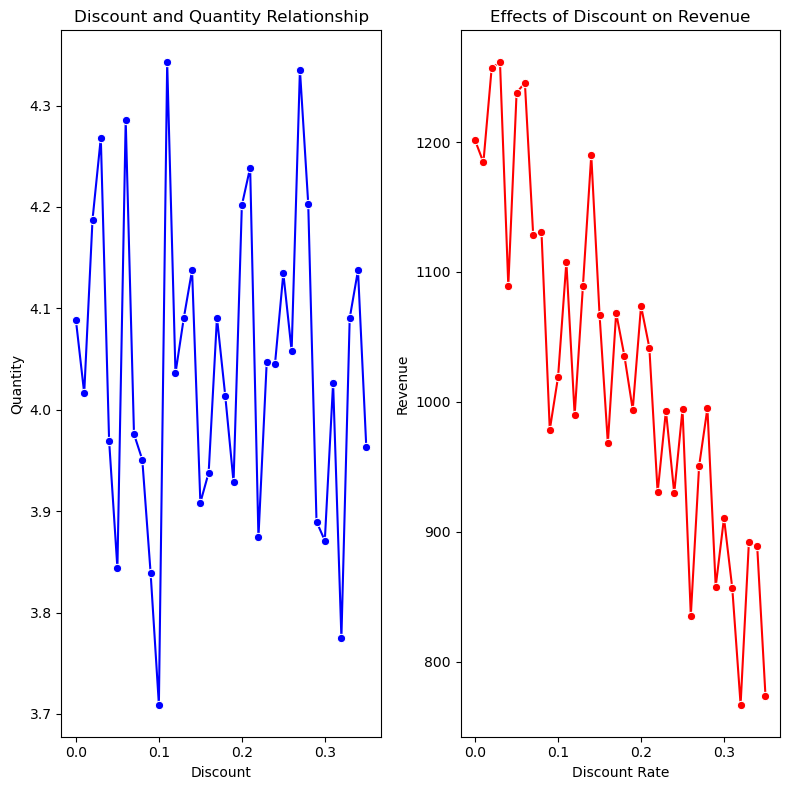

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

disc_performance=df.groupby('discount')[['quantity','revenue']].mean().reset_index()
fig,axes=plt.subplots(1,2 ,figsize=(8,8))

sns.lineplot(data=disc_performance,
            x='discount',y='quantity',ax=axes[0],color='blue',marker='o')
axes[0].set_xlabel('Discount')
axes[0].set_ylabel('Quantity')
axes[0].set_title("Discount and Quantity Relationship")

sns.lineplot(data=disc_performance,
            x='discount',
            y='revenue',ax=axes[1],color='red',marker='o')
axes[1].set_xlabel("Discount Rate")
axes[1].set_ylabel("Revenue")
axes[1].set_title("Effects of Discount on Revenue")

plt.tight_layout()
plt.show()


Observation
In the 1st relationship graph between Discount Rate and Quantity or SKUs it suggests that there is a neutral relationship between these two entities with minor fluctuations indicating higher discount didn't incentivize the quantity sold.
Now,in the 2nd relationship between Discount and Revenue there is a an inversely proportional relatiosnhip meaning when the discount rates were zero to minimum the revenue was much higher but as the higher the discount rates went the revenue can be seen dropping off and the lowest revenue was generated were when the discount rates were at its peak.

Question 4: Product Category Financial Leaks


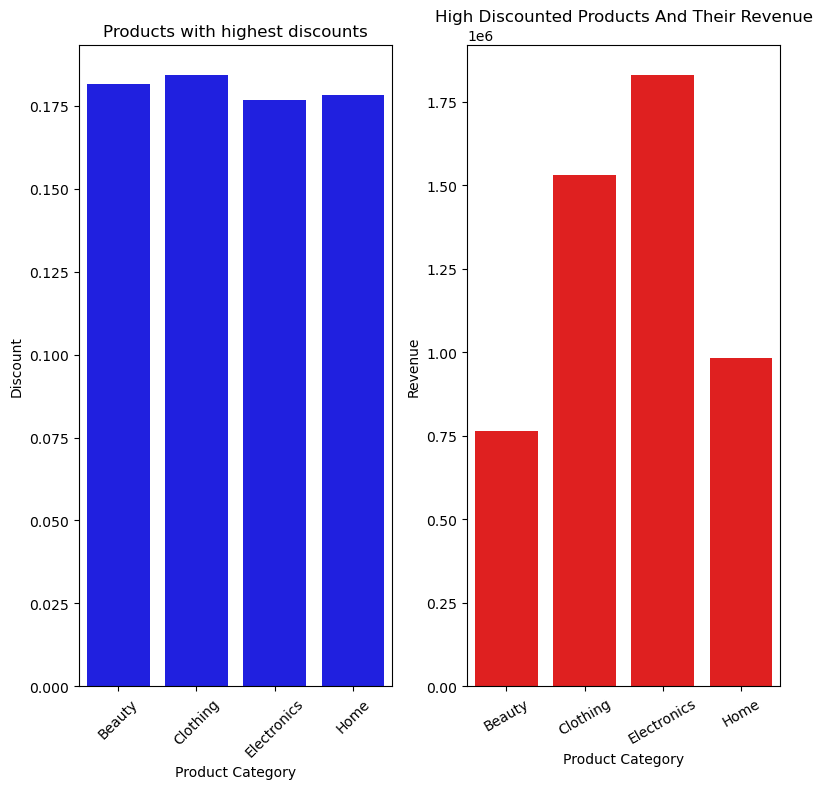

In [20]:
fig,axes=plt.subplots(1,2 ,figsize=(8,8))
cat_discount=df.groupby('product_category')['discount'].mean().reset_index()
cat_revenue=df.groupby('product_category')['revenue'].sum().reset_index()
sns.barplot(data=cat_discount,x=
            'product_category',y='discount',
            ax=axes[0],color='blue'
           )
plt.xticks(rotation=30)


axes[0].set_xlabel("Product Category")
axes[0].set_ylabel("Discount")
axes[0].set_title("Products with highest discounts")
axes[0].tick_params(axis="x",rotation=45)

sns.barplot(data=cat_revenue,x='product_category',y='revenue',ax=axes[1],color='red')
axes[1].set_xlabel("Product Category")
axes[1].set_ylabel("Revenue")
axes[1].set_title("High Discounted Products And Their Revenue")

plt.tight_layout()
plt.show()


Observation
There are four categories beauty,clothing,electronics,home.On the 1st Category vs Discount it indicates a solid discount given to all 4 categories but in the clothing category the discount rates were the highest amongst all.
In the 2nd observation,it can be observed that beauty and home category showed a revenue generated of only .75 which is low and home category if we compare both graphs the discounts given were high but the revenue in return wasn't that extraordinary.But electronics and clothing category still showed high performance in terms of revenue but each category's revenue remains under performing in terms of discount given 

Question 5: Payment Method Optimization

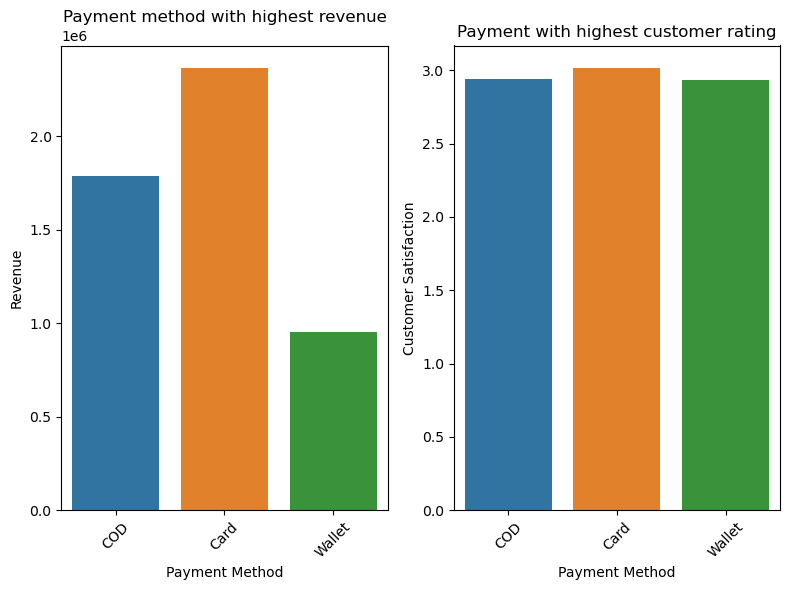

In [20]:
fig,axes=plt.subplots(1,2 ,figsize=(8,6))
payment_revenue=df.groupby('payment_method')['revenue'].sum().reset_index()
payment_score=df.groupby('payment_method')['customer_rating'].mean().reset_index()
sns.barplot(data=payment_revenue,x='payment_method',y='revenue',ax=axes[0])

axes[0].set_xlabel("Payment Method")
axes[0].set_ylabel("Revenue")
axes[0].set_title("Payment method with highest revenue")
axes[0].tick_params(axis="x",rotation=45)

sns.barplot(data=payment_score,x='payment_method',y='customer_rating',ax=axes[1])
axes[1].set_xlabel("Payment Method")
axes[1].set_ylabel("Customer Satisfaction")
axes[1].set_title("Payment with highest customer rating")
axes[1].tick_params(axis="x",rotation=45)

plt.tight_layout()
plt.show()

Observation 
The three payment methods available to the customers are COD, Wallet and Card.The COD method shows 1,750,000 in revenue and on satisfaction scale it also showed a high index of 2.8 out of 3.The card method generated the highest revenue with a whopping 2,550,000 and also stays firm at the highest 3 out of 3 rating.The wallet method generated approx 900,000 which is lowest than other two methods,but in terms of customer satisfaction it stood at a good scale of 2.8 out of 3 

Question 6: High-Value Customer Tiering (Feature Engineering)


In [8]:
import pandas as pd

# apply 

def revenue_category(row):
    if row["revenue"] > 1500:
        return "High-Value"
    else:
        return "Standard"

df["revenue_category"] = df.apply(revenue_category, axis=1)
df["revenue_category"].value_counts()


Standard      3738
High-Value    1262
Name: revenue_category, dtype: int64

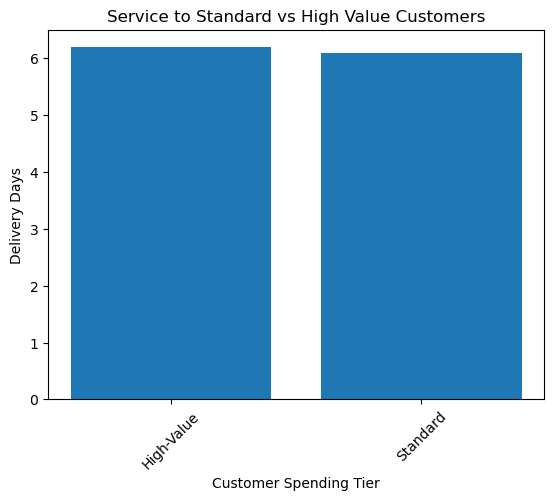

In [18]:
fig,ax=plt.subplots()
transaction=df.groupby('revenue_category')['delivery_days'].mean()
ax.bar(transaction.index,transaction.values)
ax.set_xlabel("Customer Spending Tier")
ax.set_ylabel("Delivery Days")
ax.set_title("Service to Standard vs High Value Customers")
ax.tick_params(axis="x",rotation=45)

Observation
The data divided into two categories high value customers that buy often and standard customers that are localized one.Both type of customers seem to be affected with the delivery delay but with a little more impact on high value customer,which can effect brand trust and customer loyalty in long term. 

## Executive Summary Matrix

| Investigative Area | Key Data Finding / Bottleneck | Recommended Strategic Action |
| :--- | :--- | :--- |
| **Fulfillment Limits** | Delivery delays longer than 5 days trigger a sharp drop in customer ratings. High-value spending tiers are hit slightly harder by these delays. | Implement a 5-day shipping ceiling and prioritize fulfillment logistics for premium, High-Value orders to protect brand loyalty. |
| **Discount Policies** | Higher discount rates do not drive higher purchase quantities (flat relationship) but severely erode total revenue. Clothing has the highest discount leaks, while Electronics performs best with fewer discounts. | Audit and scale back flat discount rates, especially in the Home and Clothing categories. Shift toward targeted promotions rather than blanket price cuts. |
| **Transactional Tiers** | The wallet method in terms of revenue showed the lowest performance but the showed a customer satisfaction performed at a very good scale indicating the customers are not choosing wallet method much or are making smaller purchases |To fix this bottleneck the marketing team should introduce some wallet specific promotions and check out discount codes to encourage the customers to use the wallet method more.|